In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from typing import Tuple, List, Dict
import random
from tqdm import tqdm
import math
import heapq

In [2]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IMAGE_SIZE = 33
NUM_CHANNELS = 4

Using device: cuda


### Generate maze

In [3]:
def generate_maze(width: int, height: int) -> np.ndarray:
    width = width if width % 2 == 1 else width - 1
    height = height if height % 2 == 1 else height - 1

    maze = np.ones((height, width), dtype=int)
    start_y, start_x = 1, 1
    maze[start_y, start_x] = 0

    stack = [(start_y, start_x)]
    directions = [(-2, 0), (0, 2), (2, 0), (0, -2)]

    while stack:
        current_y, current_x = stack[-1]
        random.shuffle(directions)

        found = False
        for dy, dx in directions:
            ny, nx = current_y + dy, current_x + dx
            if 1 <= ny < height - 1 and 1 <= nx < width - 1:
                if maze[ny, nx] == 1:
                    wall_y, wall_x = current_y + dy // 2, current_x + dx // 2
                    maze[wall_y, wall_x] = 0
                    maze[ny, nx] = 0
                    stack.append((ny, nx))
                    found = True
                    break

        if not found:
            stack.pop()

    # add entrance and exit
    maze[0, 1] = 0
    for x in range(width - 2, 0, -1):
        if maze[height - 2, x] == 0:
            maze[height - 1, x] = 0
            break

    return maze

In [4]:
def solve_bfs(maze: np.ndarray) -> List[Tuple[int, int]]:
    height, width = maze.shape

    # find start
    start = None
    for x in range(width):
        if maze[0, x] == 0:
            start = (0, x)
            break

    # find end
    end = None
    for x in range(width - 1, -1, -1):
        if maze[height - 1, x] == 0:
            end = (height - 1, x)
            break

    if start is None or end is None:
        return []

    queue = deque([start])
    visited = {start: None}
    directions = [(-1, 0), (0, 1), (1, 0), (0, -1)]

    while queue:
        y, x = queue.popleft()
        if (y, x) == end:
            path = []
            current = end
            while current is not None:
                path.append(current)
                current = visited[current]
            return path[::-1]

        for dy, dx in directions:
            ny, nx = y + dy, x + dx
            if (0 <= ny < height and 0 <= nx < width and
                maze[ny, nx] == 0 and (ny, nx) not in visited):
                visited[(ny, nx)] = (y, x)
                queue.append((ny, nx))

    return []

In [5]:
def render_solved_maze(maze: np.ndarray, path: List[Tuple[int, int]]) -> np.ndarray:
    # render maze with solution path
    height, width = maze.shape
    image = np.zeros((4, height, width), dtype=np.float32)

    image[0] = maze.astype(np.float32)

    if path:
        start_y, start_x = path[0]
        image[1, start_y, start_x] = 1.0
        end_y, end_x = path[-1]
        image[2, end_y, end_x] = 1.0

    for y, x in path:
        image[3, y, x] = 1.0

    return image

### Path extraction

In [6]:
def extract_path_from_prediction(maze: np.ndarray, prediction: np.ndarray,
                                  start: Tuple[int, int], end: Tuple[int, int]) -> List[Tuple[int, int]]:
    height, width = maze.shape

    # create cost map
    pred_min, pred_max = prediction.min(), prediction.max()
    if pred_max - pred_min > 0:
        cost_map = 1.0 - (prediction - pred_min) / (pred_max - pred_min)
    else:
        cost_map = np.ones_like(prediction) * 0.5

    # A* search
    def heuristic(a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    open_set = [(0, start)]
    came_from = {}
    g_score = {start: 0}
    f_score = {start: heuristic(start, end)}

    directions = [(-1, 0), (0, 1), (1, 0), (0, -1)]

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == end:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for dy, dx in directions:
            neighbor = (current[0] + dy, current[1] + dx)
            ny, nx = neighbor

            if not (0 <= ny < height and 0 <= nx < width):
                continue
            if maze[ny, nx] == 1:
                continue

            move_cost = 1.0 + cost_map[ny, nx] * 10
            tentative_g = g_score[current] + move_cost

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score[neighbor] = tentative_g + heuristic(neighbor, end)
                heapq.heappush(open_set, (f_score[neighbor], neighbor))

    return []

In [7]:
def find_start_end(condition: np.ndarray) -> Tuple[Tuple[int, int], Tuple[int, int]]:
    # find start and end positions from condition tensor
    start_channel = condition[1]
    end_channel = condition[2]

    start_pos = np.unravel_index(np.argmax(start_channel), start_channel.shape)
    end_pos = np.unravel_index(np.argmax(end_channel), end_channel.shape)

    return tuple(start_pos), tuple(end_pos)

### Dataset

In [8]:
def create_dataset_sample(image_size: int = IMAGE_SIZE) -> Tuple[torch.Tensor, torch.Tensor]:
    # single dataset sample
    maze = generate_maze(image_size, image_size)
    path = solve_bfs(maze)
    solved_maze = render_solved_maze(maze, path)

    condition = torch.from_numpy(solved_maze[0:3]).float()
    target_path = torch.from_numpy(solved_maze[3:4]).float()

    return condition, target_path


In [9]:
def create_dataloader(size: int, batch_size: int, image_size: int = IMAGE_SIZE):
    # pre-generate all samples
    samples = [create_dataset_sample(image_size) for _ in range(size)]

    # create batches
    def collate_fn(batch):
        conditions = torch.stack([item[0] for item in batch])
        targets = torch.stack([item[1] for item in batch])
        return conditions, targets

    dataset = torch.utils.data.TensorDataset(
        torch.stack([s[0] for s in samples]),
        torch.stack([s[1] for s in samples])
    )

    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

### Diffusion process

In [10]:
def create_diffusion_schedule(num_timesteps: int = 1000, beta_start: float = 0.0001,
                               beta_end: float = 0.02) -> Dict[str, torch.Tensor]:
    betas = torch.linspace(beta_start, beta_end, num_timesteps)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)

    return {
        'betas': betas.to(device),
        'alphas': alphas.to(device),
        'alpha_bars': alpha_bars.to(device),
        'num_timesteps': num_timesteps
    }

In [11]:
def add_noise(x0: torch.Tensor, t: torch.Tensor, schedule: Dict, noise: torch.Tensor = None) -> torch.Tensor:
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_alpha_bar_t = torch.sqrt(schedule['alpha_bars'][t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - schedule['alpha_bars'][t]).view(-1, 1, 1, 1)

    return sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise


In [12]:
def sample_timesteps(batch_size: int, num_timesteps: int) -> torch.Tensor:
    return torch.randint(0, num_timesteps, (batch_size,), device=device)


In [13]:
@torch.no_grad()
def sample_diffusion(model: nn.Module, condition: torch.Tensor, schedule: Dict,
                     num_steps: int = None, show_progress: bool = True) -> torch.Tensor:
    if num_steps is None:
        num_steps = schedule['num_timesteps']

    batch_size = condition.shape[0]
    h, w = condition.shape[2], condition.shape[3]

    path = torch.randn(batch_size, 1, h, w, device=device)

    timesteps = torch.linspace(schedule['num_timesteps'] - 1, 0, num_steps, dtype=torch.long, device=device)

    iterator = tqdm(timesteps, desc="Denoising", leave=False) if show_progress else timesteps

    for t in iterator:
        t_batch = t.expand(batch_size)
        x_input = torch.cat([condition, path], dim=1)
        noise_pred = model(x_input, t_batch)

        alpha = schedule['alphas'][t]
        alpha_bar = schedule['alpha_bars'][t]
        beta = schedule['betas'][t]

        if t > 0:
            alpha_bar_prev = schedule['alpha_bars'][t - 1]
            noise = torch.randn_like(path)
            sigma = torch.sqrt(beta * (1 - alpha_bar_prev) / (1 - alpha_bar))
        else:
            sigma = 0
            noise = 0

        path = (1 / torch.sqrt(alpha)) * (
            path - (beta / torch.sqrt(1 - alpha_bar)) * noise_pred
        ) + sigma * noise

    return path


### U-NET model

In [14]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        return torch.cat([embeddings.sin(), embeddings.cos()], dim=-1)


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, up=False, down=False):
        super().__init__()
        self.up = up

        if down:
            self.conv = nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1)
        else:
            self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.time_mlp = nn.Linear(time_dim, out_ch)

    def forward(self, x, time_emb, target_size=None):
        if self.up and target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)

        x = self.conv(x)
        x = self.norm(x)
        x = x + self.time_mlp(time_emb)[:, :, None, None]
        return self.act(x)


class MazeSolvingUNet(nn.Module):
    def __init__(self, in_ch=4, out_ch=1, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU()
        )

        self.down1 = Block(in_ch, 64, time_dim)
        self.down2 = Block(64, 128, time_dim, down=True)
        self.down3 = Block(128, 256, time_dim, down=True)
        self.down4 = Block(256, 512, time_dim, down=True)

        self.bottleneck = Block(512, 512, time_dim)

        self.up1 = Block(512 + 512, 256, time_dim, up=True)
        self.up2 = Block(256 + 256, 128, time_dim, up=True)
        self.up3 = Block(128 + 128, 64, time_dim, up=True)
        self.up4 = Block(64 + 64, 64, time_dim)

        self.out = nn.Sequential(
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv2d(64, out_ch, 3, padding=1)
        )

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)

        x1 = self.down1(x, t)
        x2 = self.down2(x1, t)
        x3 = self.down3(x2, t)
        x4 = self.down4(x3, t)

        x = self.bottleneck(x4, t)

        x = self.up1(torch.cat([x, x4], 1), t, x3.shape[2:])
        x = self.up2(torch.cat([x, x3], 1), t, x2.shape[2:])
        x = self.up3(torch.cat([x, x2], 1), t, x1.shape[2:])
        x = self.up4(torch.cat([x, x1], 1), t)

        return self.out(x)

### Training

In [15]:
def train_epoch(model: nn.Module, dataloader, schedule: Dict, optimizer) -> float:
    model.train()
    total_loss = 0

    for condition, target_path in tqdm(dataloader, desc="Training", leave=False):
        condition = (condition.to(device) * 2.0 - 1.0)
        target_path = (target_path.to(device) * 2.0 - 1.0)

        t = sample_timesteps(condition.shape[0], schedule['num_timesteps'])
        noise = torch.randn_like(target_path)
        path_noisy = add_noise(target_path, t, schedule, noise)

        x_input = torch.cat([condition, path_noisy], dim=1)
        noise_pred = model(x_input, t)

        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [16]:
# evaluation
def check_path_validity(maze: np.ndarray, path: List[Tuple[int, int]]) -> bool:
    # check if path doesn't go through walls
    if not path:
        return False
    for y, x in path:
        if maze[y, x] == 1:  # Wall
            return False
    return True


def check_path_success(path: List[Tuple[int, int]], start: Tuple[int, int], end: Tuple[int, int]) -> bool:
    # check if path successfully connects start to end
    if not path or len(path) < 2:
        return False
    return path[0] == start and path[-1] == end


def calculate_path_length_ratio(predicted_path: List[Tuple[int, int]],
                                 ground_truth_path: List[Tuple[int, int]]) -> float:
    # calculate ratio of predicted path length to optimal path length
    if not ground_truth_path or not predicted_path:
        return float('inf')
    return len(predicted_path) / len(ground_truth_path)


def calculate_path_overlap(predicted_path: List[Tuple[int, int]],
                           ground_truth_path: List[Tuple[int, int]]) -> float:
    # calculate percentage of overlap between predicted and ground truth paths
    if not ground_truth_path:
        return 0.0

    pred_set = set(predicted_path)
    gt_set = set(ground_truth_path)
    overlap = len(pred_set & gt_set)

    return overlap / len(gt_set)


def evaluate_single_maze(model: nn.Module, schedule: Dict, image_size: int = IMAGE_SIZE) -> Dict[str, float]:
    # evaluate model on a single maze
    maze = generate_maze(image_size, image_size)
    gt_path = solve_bfs(maze)
    solved = render_solved_maze(maze, gt_path)

    # prepare input
    condition = torch.from_numpy(solved[0:3]).float().unsqueeze(0).to(device)
    condition_norm = condition * 2.0 - 1.0

    # get prediction
    with torch.no_grad():
        raw_pred = sample_diffusion(model, condition_norm, schedule, num_steps=200)
    raw_pred_np = raw_pred[0, 0].cpu().numpy()

    # extract path
    start, end = find_start_end(solved[0:3])
    predicted_path = extract_path_from_prediction(maze, raw_pred_np, start, end)

    # calculate metrics
    is_valid = check_path_validity(maze, predicted_path)
    is_success = check_path_success(predicted_path, start, end)
    length_ratio = calculate_path_length_ratio(predicted_path, gt_path)
    overlap = calculate_path_overlap(predicted_path, gt_path)

    return {
        'valid': is_valid,
        'success': is_success,
        'length_ratio': length_ratio if is_success else float('inf'),
        'overlap': overlap,
        'predicted_length': len(predicted_path),
        'gt_length': len(gt_path)
    }


def evaluate_model(model: nn.Module, schedule: Dict, num_samples: int = 10000,
                   image_size: int = IMAGE_SIZE) -> Dict[str, float]:
    # evaluate model on multiple test mazes
    print(f"\nEvaluating model on {num_samples} test mazes...")
    model.eval()

    results = {
        'valid': [],
        'success': [],
        'length_ratio': [],
        'overlap': []
    }

    for i in tqdm(range(num_samples), desc="Evaluating"):
        metrics = evaluate_single_maze(model, schedule, image_size)

        results['valid'].append(metrics['valid'])
        results['success'].append(metrics['success'])
        if metrics['success']:
            results['length_ratio'].append(metrics['length_ratio'])
            results['overlap'].append(metrics['overlap'])

    # calculate summary statistics
    summary = {
        'success_rate': np.mean(results['success']) * 100,
        'valid_path_rate': np.mean(results['valid']) * 100,
        'avg_length_ratio': np.mean(results['length_ratio']) if results['length_ratio'] else float('inf'),
        'avg_overlap': np.mean(results['overlap']) if results['overlap'] else 0.0,
        'total_samples': num_samples,
        'successful_samples': sum(results['success'])
    }

    return summary


def print_evaluation_results(summary: Dict[str, float]):
    # print evaluation results
    print("\n" + "=" * 60)
    print("EVALUATION RESULTS")
    print("=" * 60)
    print(f"Total samples evaluated: {summary['total_samples']}")
    print(f"Successful samples: {summary['successful_samples']}")
    print(f"\nSuccess Rate: {summary['success_rate']:.2f}%")
    print(f"Valid Path Rate: {summary['valid_path_rate']:.2f}%")
    print(f"Average Path Length Ratio: {summary['avg_length_ratio']:.4f}")
    print(f"Average Path Overlap: {summary['avg_overlap']:.4f} ({summary['avg_overlap']*100:.2f}%)")
    print("=" * 60)


def visualize_epoch_progress(model: nn.Module, schedule: Dict, test_maze_data: Dict,
                             epoch: int, save_path: str = None):
    # visualize model performance on a fixed test maze
    maze = test_maze_data['maze']
    gt_path = test_maze_data['gt_path']
    solved = test_maze_data['solved']

    # prepare input
    condition = torch.from_numpy(solved[0:3]).float().unsqueeze(0).to(device)
    condition_norm = condition * 2.0 - 1.0

    # get prediction
    model.eval()
    with torch.no_grad():
        raw_pred = sample_diffusion(model, condition_norm, schedule, num_steps=200, show_progress=False)
    raw_pred_np = raw_pred[0, 0].cpu().numpy()

    # extract path
    start, end = find_start_end(solved[0:3])
    predicted_path = extract_path_from_prediction(maze, raw_pred_np, start, end)

    # calculate metrics
    is_success = check_path_success(predicted_path, start, end)
    length_ratio = calculate_path_length_ratio(predicted_path, gt_path)
    overlap = calculate_path_overlap(predicted_path, gt_path)

    # visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    h, w = condition.shape[2], condition.shape[3]

    # unsolved maze
    unsolved = np.zeros((h, w, 3))
    unsolved[:, :, 0] = solved[0]
    unsolved[:, :, 1] = solved[1] + solved[2]
    axes[0].imshow(unsolved, interpolation='nearest')
    axes[0].set_title("Test Maze")
    axes[0].axis('off')

    # prediction heatmap
    axes[1].imshow(raw_pred_np, cmap='coolwarm', interpolation='nearest')
    axes[1].set_title(f"Prediction")
    axes[1].axis('off')

    # extracted path
    solved_img = unsolved.copy()
    for y, x in predicted_path:
        solved_img[y, x] = [0.2, 0.4, 1.0]
    axes[2].imshow(solved_img, interpolation='nearest')
    axes[2].set_title(f"Len: {len(predicted_path)}/{len(gt_path)} | Ratio: {length_ratio:.2f} | Overlap: {overlap:.2f}")
    axes[2].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
    plt.show()
    plt.close()


1. Creating dataset (50,000 mazes)...

2. Initializing model...
   Parameters: 7,219,969

3. Training for 10 epochs...


   Epoch 1/10 - Loss: 0.062511


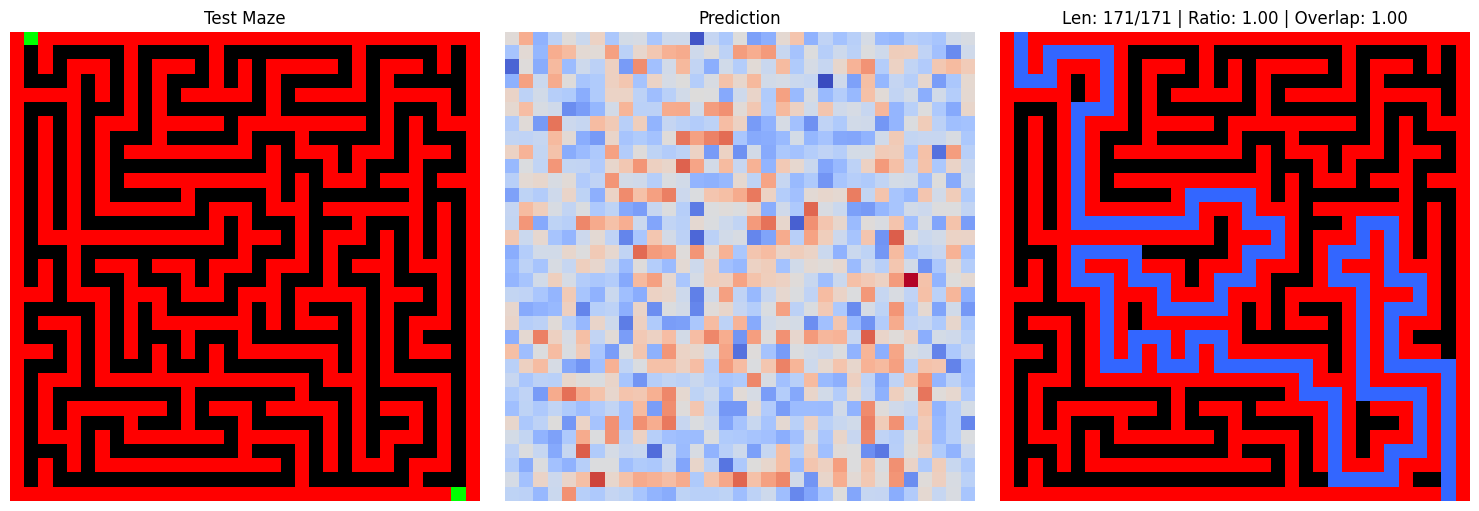

   Epoch 2/10 - Loss: 0.016762


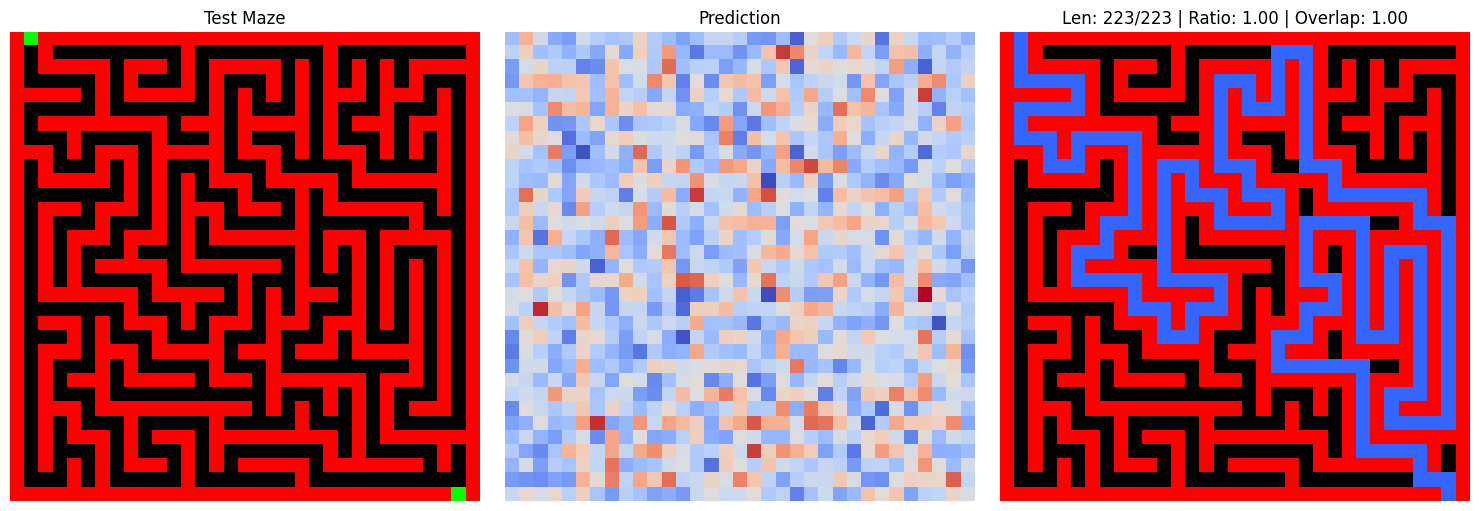

   Epoch 3/10 - Loss: 0.011779


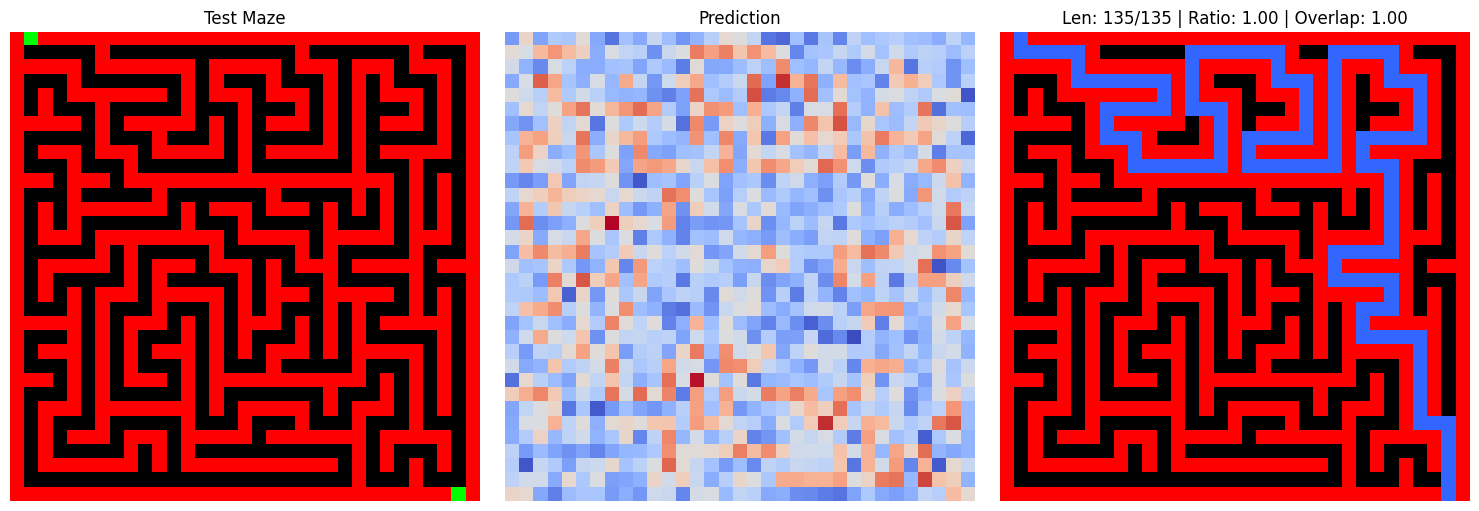

   Epoch 4/10 - Loss: 0.009230


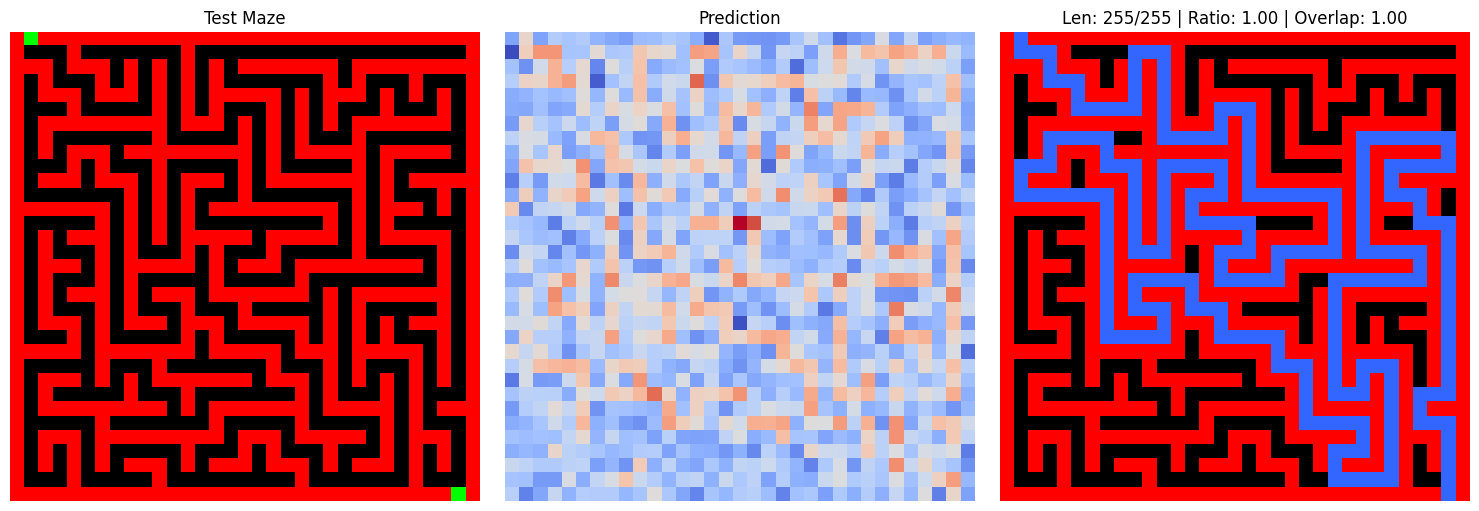

   Epoch 5/10 - Loss: 0.007655


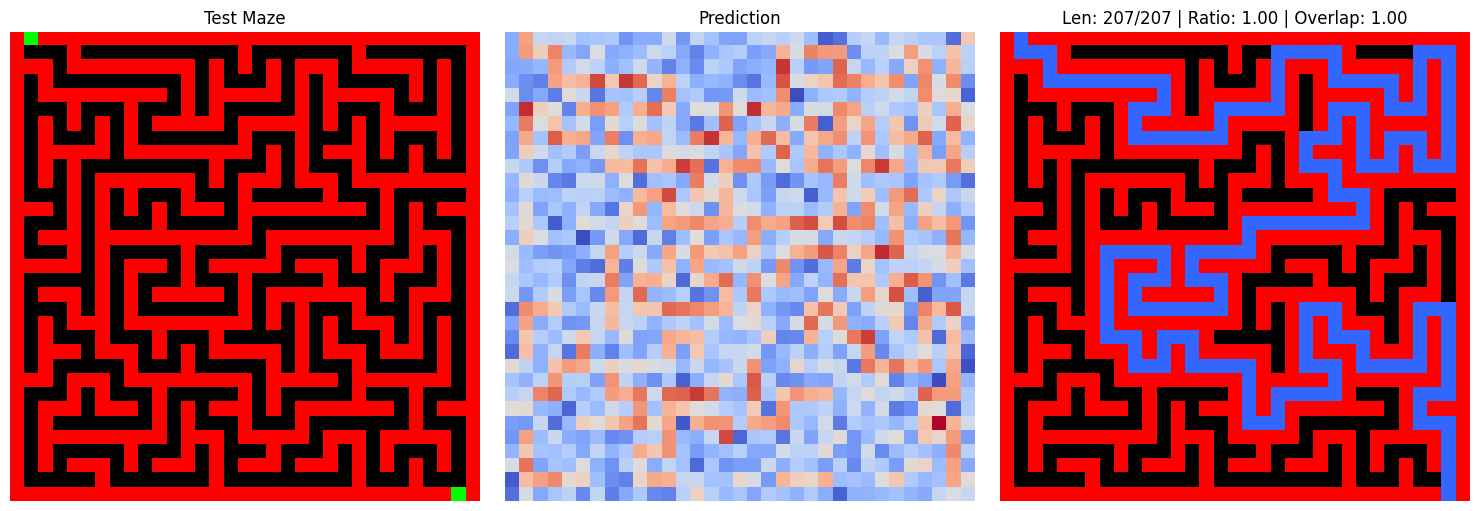

   Epoch 6/10 - Loss: 0.006624


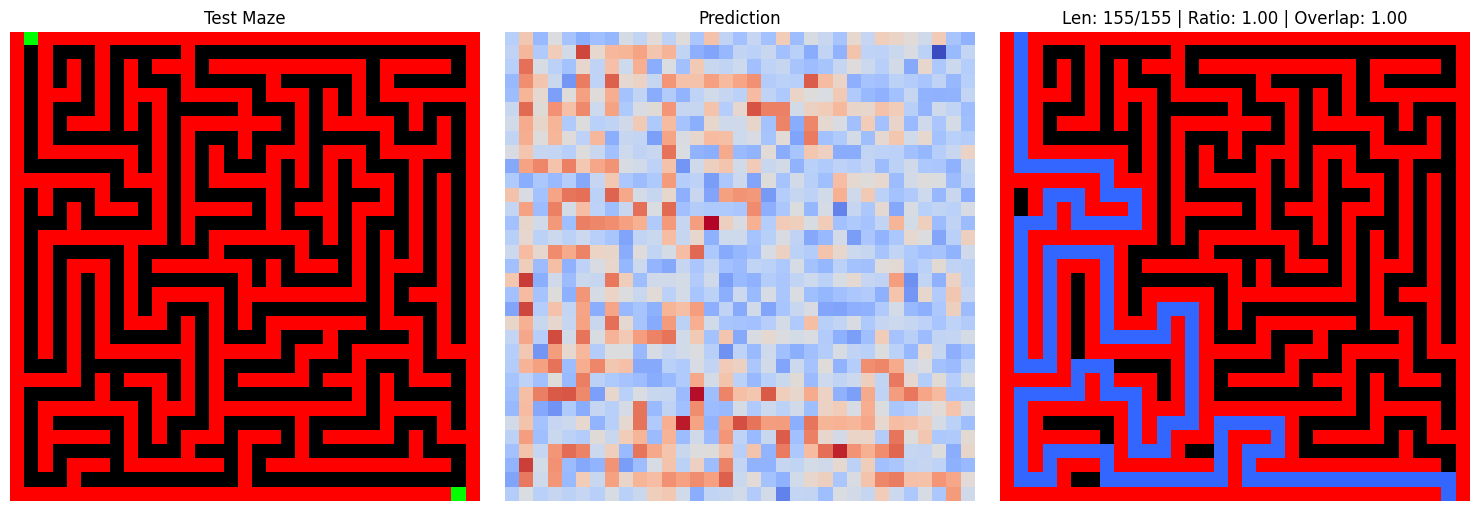

   Epoch 7/10 - Loss: 0.005709


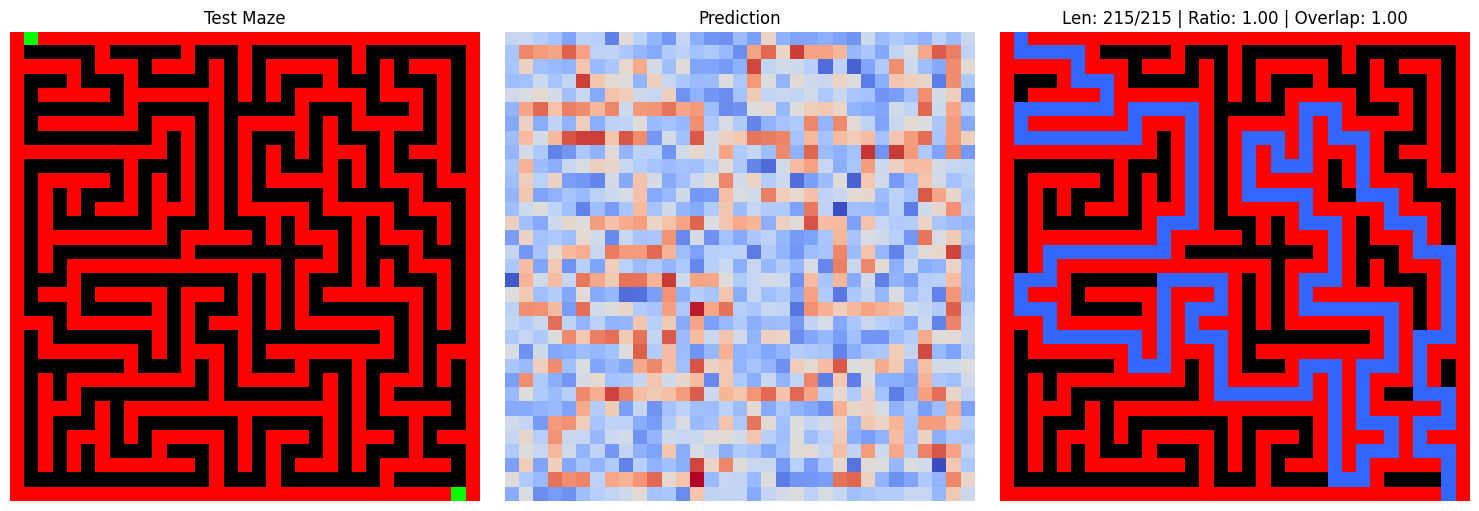

   Epoch 8/10 - Loss: 0.004821


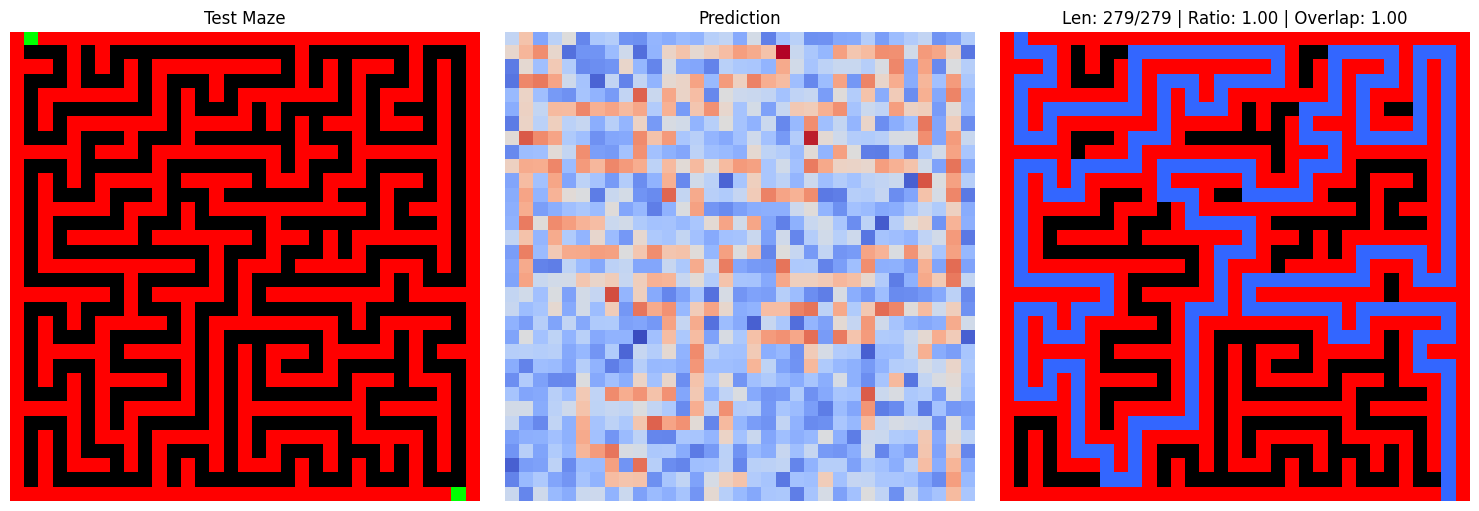

   Epoch 9/10 - Loss: 0.004720


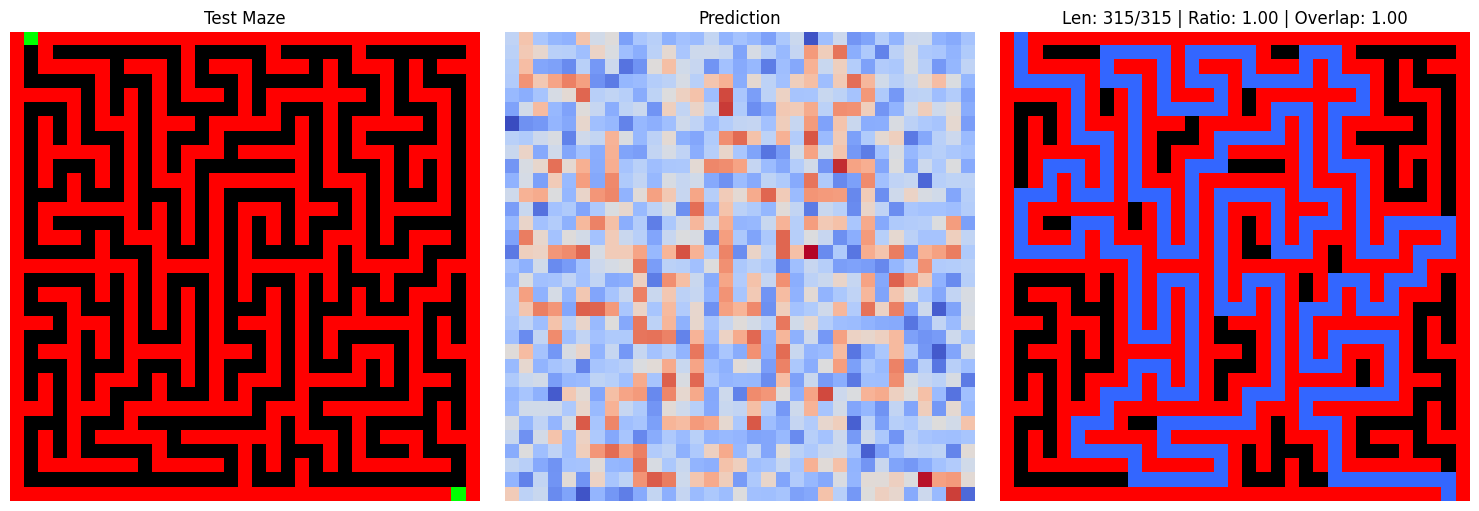

   Epoch 10/10 - Loss: 0.004145


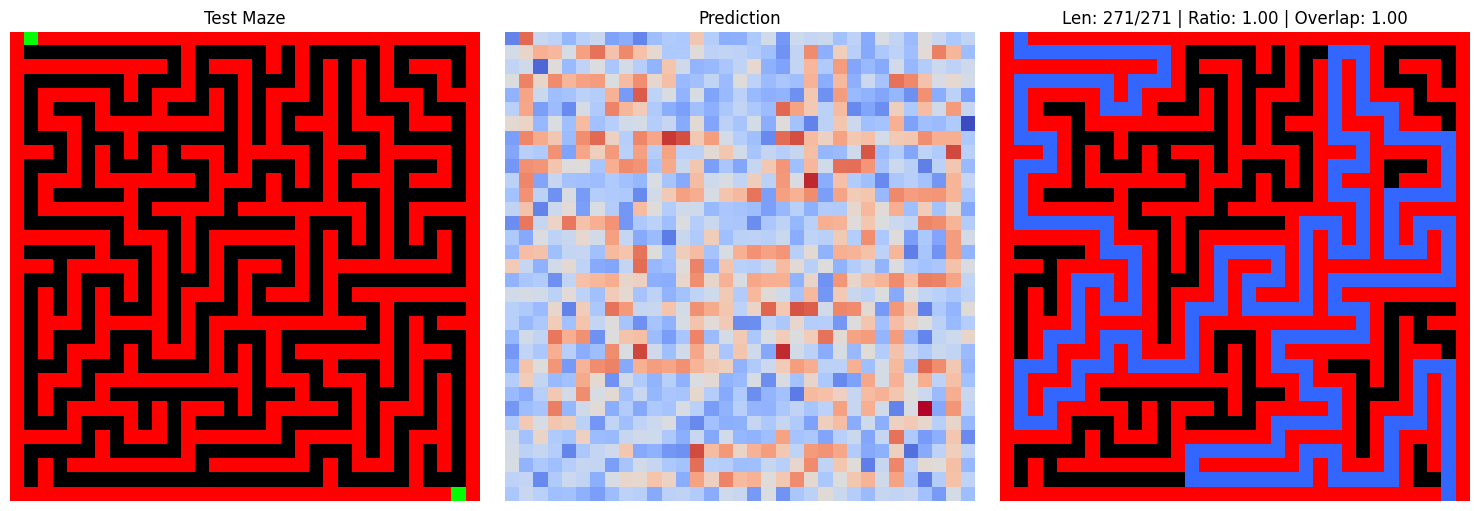

   → Saved checkpoint

   Training complete!


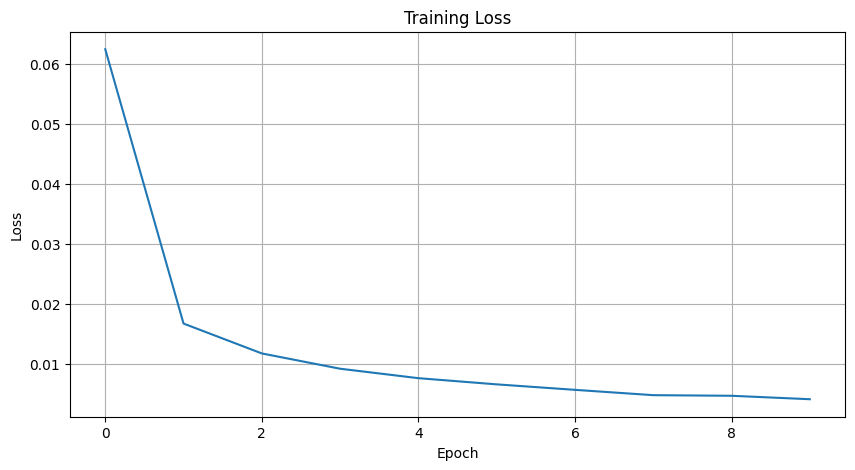


5. Running comprehensive evaluation on 500 test mazes...

Evaluating model on 500 test mazes...


Evaluating: 100%|██████████| 500/500 [07:10<00:00,  1.16it/s]



EVALUATION RESULTS
Total samples evaluated: 500
Successful samples: 500

Success Rate: 100.00%
Valid Path Rate: 100.00%
Average Path Length Ratio: 1.0000
Average Path Overlap: 1.0000 (100.00%)

6. Testing on random mazes for visualization...

   Solving maze 1...


   GT path: 127, Extracted: 127
   Success: True, Length Ratio: 1.00, Overlap: 1.00


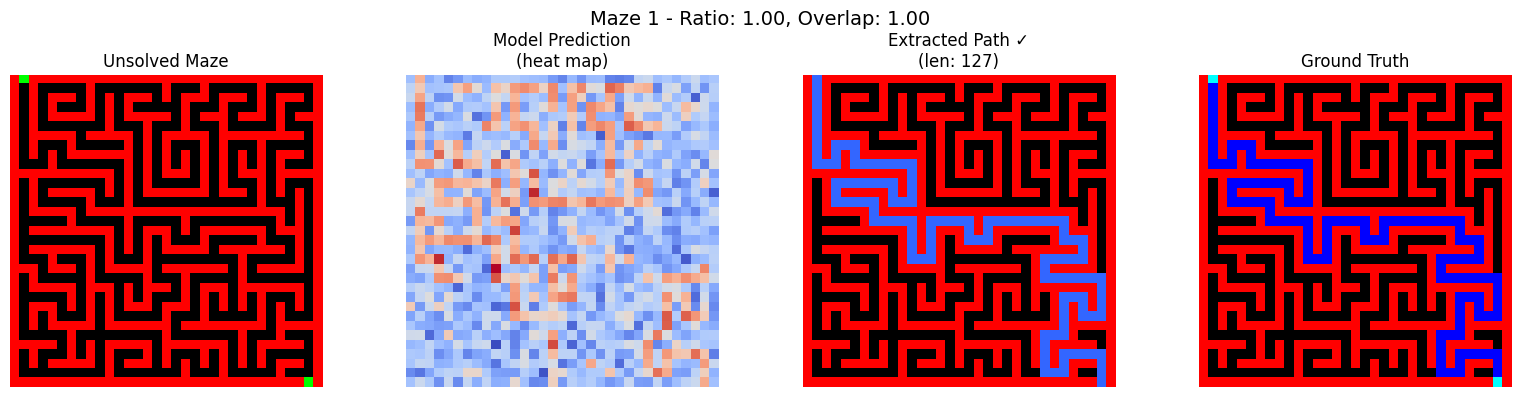


   Solving maze 2...


   GT path: 303, Extracted: 303
   Success: True, Length Ratio: 1.00, Overlap: 1.00


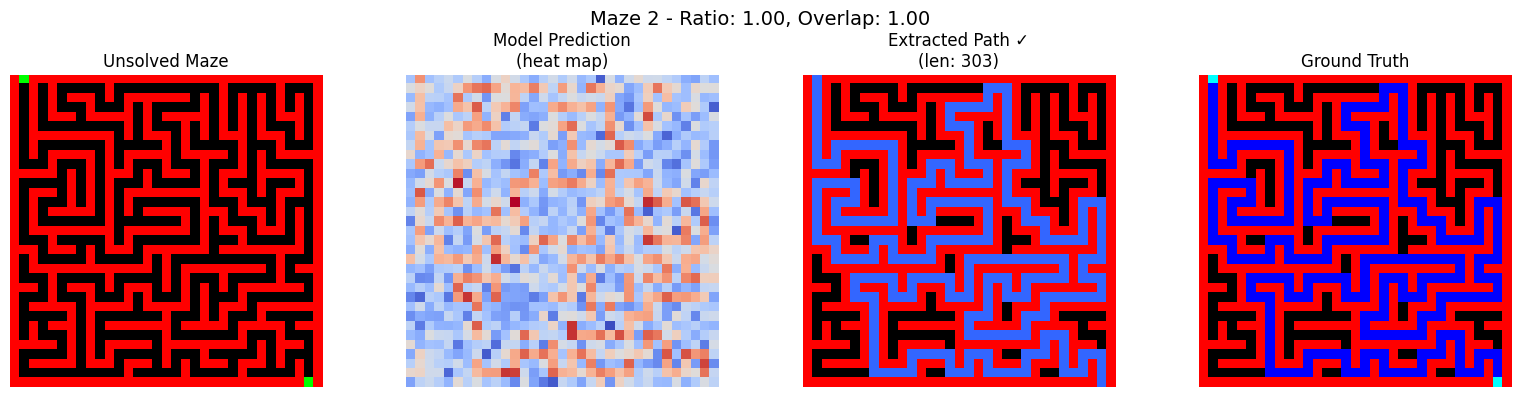


   Solving maze 3...


   GT path: 259, Extracted: 259
   Success: True, Length Ratio: 1.00, Overlap: 1.00


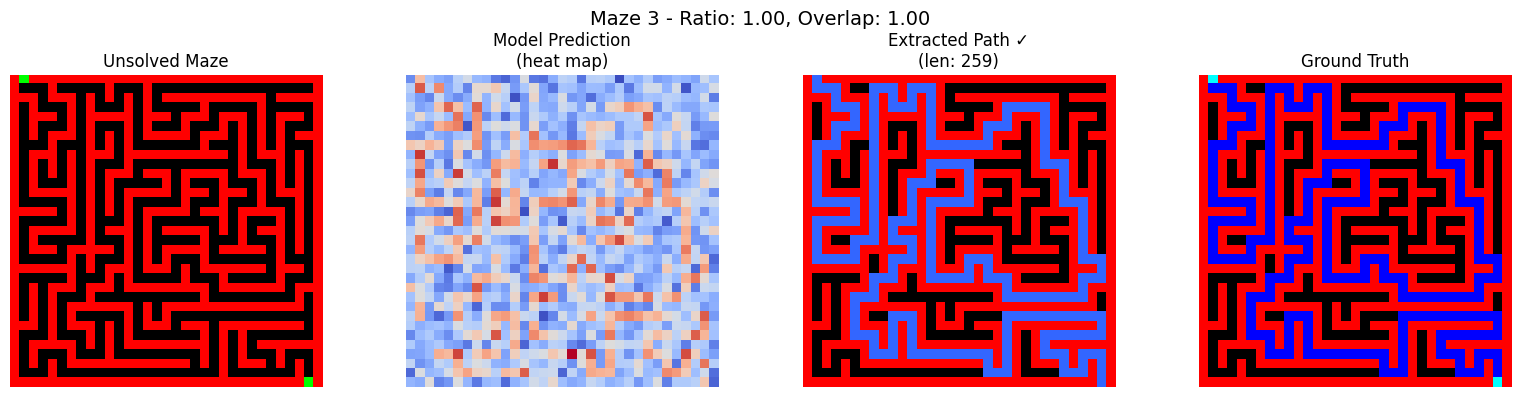


   Solving maze 4...


   GT path: 183, Extracted: 183
   Success: True, Length Ratio: 1.00, Overlap: 1.00


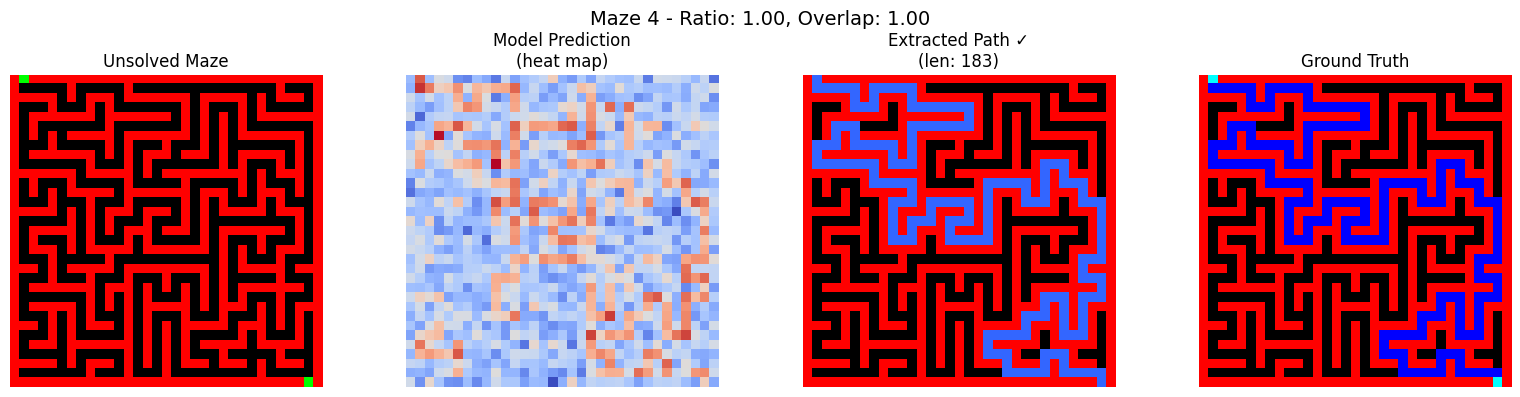


Done!


In [17]:
def main():
    # create dataset
    print("\n1. Creating dataset (50,000 mazes)...")
    dataloader = create_dataloader(size=50000, batch_size=64, image_size=IMAGE_SIZE)

    # initialize
    print("\n2. Initializing model...")
    model = MazeSolvingUNet(in_ch=4, out_ch=1, time_dim=64).to(device)
    schedule = create_diffusion_schedule(num_timesteps=1000)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # training
    print("\n3. Training for 10 epochs...")
    NUM_EPOCHS = 10
    losses = []

    for epoch in range(1, NUM_EPOCHS + 1):
        loss = train_epoch(model, dataloader, schedule, optimizer)
        scheduler.step()
        losses.append(loss)

        print(f"   Epoch {epoch}/{NUM_EPOCHS} - Loss: {loss:.6f}", flush=True)

        # generate a fresh random maze
        test_maze = generate_maze(IMAGE_SIZE, IMAGE_SIZE)
        test_gt_path = solve_bfs(test_maze)
        test_solved = render_solved_maze(test_maze, test_gt_path)
        test_maze_data = {
            'maze': test_maze,
            'gt_path': test_gt_path,
            'solved': test_solved
        }
        visualize_epoch_progress(model, schedule, test_maze_data, epoch,
                                save_path=f'epoch_{epoch}_test_maze.png')

        if epoch % 10 == 0:
            torch.save(model.state_dict(), f'maze_solver_functional_epoch_{epoch}.pt')
            print(f"   → Saved checkpoint", flush=True)

    print("\n   Training complete!")

    # plot loss curve
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.savefig('training_loss_functional.png')
    plt.show()

    # evaluation on 10,000 test mazes
    print("\n5. Running comprehensive evaluation on 500 test mazes...")
    summary = evaluate_model(model, schedule, num_samples=500, image_size=IMAGE_SIZE)
    print_evaluation_results(summary)

    # save evaluation results
    import json
    with open('evaluation_results.json', 'w') as f:
        json.dump(summary, f, indent=2)

    # test on a few random mazes
    print("\n6. Testing on random mazes for visualization...")
    model.eval()

    for i in range(4):
        print(f"\n   Solving maze {i+1}...")

        # generate a new maze
        maze = generate_maze(IMAGE_SIZE, IMAGE_SIZE)
        gt_path_list = solve_bfs(maze)
        solved = render_solved_maze(maze, gt_path_list)

        condition = torch.from_numpy(solved[0:3]).float().unsqueeze(0).to(device)
        condition_norm = condition * 2.0 - 1.0
        gt_path = solved[3:4]

        # get model prediction
        with torch.no_grad():
            raw_pred = sample_diffusion(model, condition_norm, schedule, num_steps=200)
        raw_pred_np = raw_pred[0, 0].cpu().numpy()

        # extract path using A*
        start, end = find_start_end(solved[0:3])
        extracted_path = extract_path_from_prediction(maze, raw_pred_np, start, end)

        # calculate metrics
        is_success = check_path_success(extracted_path, start, end)
        length_ratio = calculate_path_length_ratio(extracted_path, gt_path_list)
        overlap = calculate_path_overlap(extracted_path, gt_path_list)

        print(f"   GT path: {len(gt_path_list)}, Extracted: {len(extracted_path)}")
        print(f"   Success: {is_success}, Length Ratio: {length_ratio:.2f}, Overlap: {overlap:.2f}")

        # visualize
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        h, w = condition.shape[2], condition.shape[3]

        # unsolved
        unsolved = np.zeros((h, w, 3))
        unsolved[:, :, 0] = solved[0]
        unsolved[:, :, 1] = solved[1] + solved[2]
        axes[0].imshow(unsolved, interpolation='nearest')
        axes[0].set_title("Unsolved Maze")
        axes[0].axis('off')

        # raw prediction
        axes[1].imshow(raw_pred_np, cmap='coolwarm', interpolation='nearest')
        axes[1].set_title("Model Prediction\n(heat map)")
        axes[1].axis('off')

        # extracted path
        solved_img = unsolved.copy()
        for y, x in extracted_path:
            solved_img[y, x] = [0.2, 0.4, 1.0]
        axes[2].imshow(solved_img, interpolation='nearest')
        status = "✓" if is_success else "✗"
        axes[2].set_title(f"Extracted Path {status}\n(len: {len(extracted_path)})")
        axes[2].axis('off')

        # ground truth
        gt_img = unsolved.copy()
        gt_img[:, :, 2] = np.clip(gt_img[:, :, 2] + gt_path[0], 0, 1)
        axes[3].imshow(gt_img, interpolation='nearest')
        axes[3].set_title("Ground Truth")
        axes[3].axis('off')

        plt.suptitle(f"Maze {i+1} - Ratio: {length_ratio:.2f}, Overlap: {overlap:.2f}", fontsize=14)
        plt.tight_layout()
        plt.savefig(f'final_test_maze_{i+1}.png')
        plt.show()

    print("\nDone!")


if __name__ == "__main__":
    main()
